### Importação dos dados



In [1]:
import pandas as pd
import matplotlib.pyplot as plt


url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()



,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento



In [2]:
lojas = [loja, loja2, loja3, loja4]
nomes = ["Loja 1", "Loja 2","Loja 3", "Loja 4"]
for nome, loja in zip(nomes, lojas):
  faturamento = loja['Preço'].sum()
  print(f"{nome} faturamento total: R${faturamento:,.2f}")
  todas_as_lojas = pd.concat(lojas)
  faturamento_total = todas_as_lojas['Preço'].sum()
  print("\n📊 Faturamento total geral de todas as lojas: R$", round(faturamento_total, 2))


Loja 1 faturamento total: R$1,534,509.12

📊 Faturamento total geral de todas as lojas: R$ 5871490.79
Loja 2 faturamento total: R$1,488,459.06

📊 Faturamento total geral de todas as lojas: R$ 5871490.79
Loja 3 faturamento total: R$1,464,025.03

📊 Faturamento total geral de todas as lojas: R$ 5871490.79
Loja 4 faturamento total: R$1,384,497.58

📊 Faturamento total geral de todas as lojas: R$ 5871490.79


# 2. Vendas por Categoria

In [3]:
lojas = [loja, loja2, loja3, loja4]
nomes = ["Loja 1", "Loja 2", "Loja 3", "Loja 4"]

for nome, loja in zip(nomes, lojas):
  print(f"\n{nome}")
  categorias = loja.groupby('Categoria do Produto')['Produto'].count().sort_values(ascending=False)
  print("Categorias mais vendidas")
  print(categorias)


Loja 1
Categorias mais vendidas
Categoria do Produto
moveis                   480
eletronicos              451
brinquedos               338
esporte e lazer          277
eletrodomesticos         254
utilidades domesticas    201
livros                   187
instrumentos musicais    170
Name: Produto, dtype: int64

Loja 2
Categorias mais vendidas
Categoria do Produto
moveis                   442
eletronicos              422
brinquedos               313
eletrodomesticos         305
esporte e lazer          275
instrumentos musicais    224
livros                   197
utilidades domesticas    181
Name: Produto, dtype: int64

Loja 3
Categorias mais vendidas
Categoria do Produto
moveis                   499
eletronicos              451
brinquedos               315
eletrodomesticos         278
esporte e lazer          277
livros                   185
instrumentos musicais    177
utilidades domesticas    177
Name: Produto, dtype: int64

Loja 4
Categorias mais vendidas
Categoria do Produto
move

# 3. Média de Avaliação das Lojas


In [4]:
lojas = [loja, loja2, loja3, loja4]
nomes = ["Loja 1", "Loja 2", "Loja 3", "Loja 4"]
avaliacoes = {}
for nome, loja in zip(nomes, lojas):
  media = loja['Avaliação da compra'].mean()
  avaliacoes[nome] = media
df_avaliacoes = pd.DataFrame.from_dict(avaliacoes, orient='index', columns=['Média de Avaliação'])
ranking = df_avaliacoes.sort_values(by='Média de Avaliação', ascending=False)
print(ranking)


        Média de Avaliação
Loja 3            4.048326
Loja 2            4.037304
Loja 1            3.995759
Loja 4            3.995759


# 4. Produtos Mais e Menos Vendidos

In [5]:
for nome, loja in zip(nomes, lojas):
  print(f"\n {nome}")

  produtos = loja['Produto'].value_counts()
  mais_vendidos = produtos.head(3)
  menos_vendidos = produtos.tail(3)
  print("🔥 Top 3 produtos mais vendidos:")
  print(mais_vendidos)
  print("\n⚠️ 3 produtos com menos vendas:")
  print(menos_vendidos)


 Loja 1
🔥 Top 3 produtos mais vendidos:
Produto
Cama box                   62
Faqueiro                   59
Dashboards com Power BI    56
Name: count, dtype: int64

⚠️ 3 produtos com menos vendas:
Produto
Violão           37
Guarda roupas    34
Guitarra         33
Name: count, dtype: int64

 Loja 2
🔥 Top 3 produtos mais vendidos:
Produto
Iniciando em programação    65
Micro-ondas                 62
Bateria                     61
Name: count, dtype: int64

⚠️ 3 produtos com menos vendas:
Produto
Mesa de jantar       34
Impressora           34
Jogo de tabuleiro    32
Name: count, dtype: int64

 Loja 3
🔥 Top 3 produtos mais vendidos:
Produto
Kit banquetas     57
Mesa de jantar    56
Cama king         56
Name: count, dtype: int64

⚠️ 3 produtos com menos vendas:
Produto
Mochila             36
Micro-ondas         36
Blocos de montar    35
Name: count, dtype: int64

 Loja 4
🔥 Top 3 produtos mais vendidos:
Produto
Cama box                   62
Faqueiro                   59
Dashboards com Pow

# 5. Frete Médio por Loja

In [6]:
lojas = [loja, loja2, loja3, loja4]
nomes = ["Loja 1", "Loja 2","Loja 3", "Loja 4"]
for nome, loja in zip(nomes, lojas):
  print(f"{nome}")
  frete_medio = loja['Frete'].mean()
  print("Frete médio: R$", round(frete_medio, 2))


Loja 1
Frete médio: R$ 31.28
Loja 2
Frete médio: R$ 33.62
Loja 3
Frete médio: R$ 33.07
Loja 4
Frete médio: R$ 31.28


# GRÁFICO 1 — Faturamento total por loja

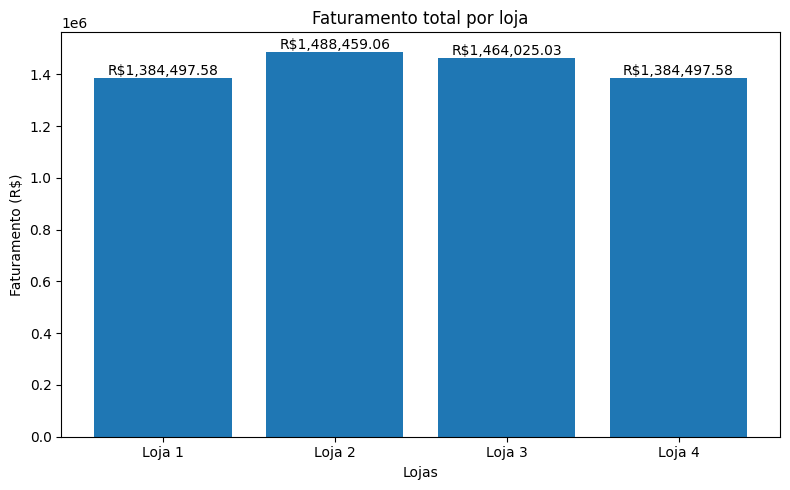

In [7]:



faturamentos = [loja['Preço'].sum(), loja2['Preço'].sum(),
                loja3['Preço'].sum(), loja4['Preço'].sum()]

plt.figure(figsize=(8,5))
plt.bar(nomes, faturamentos)


for i, valor in enumerate(faturamentos):
    plt.text(i, valor, f"R${valor:,.2f}", ha='center', va='bottom')

plt.title("Faturamento total por loja")
plt.xlabel("Lojas")
plt.ylabel("Faturamento (R$)")
plt.tight_layout()
plt.show()


# GRÁFICO 2 — Distribuição das categorias mais vendidas (PIZZA)

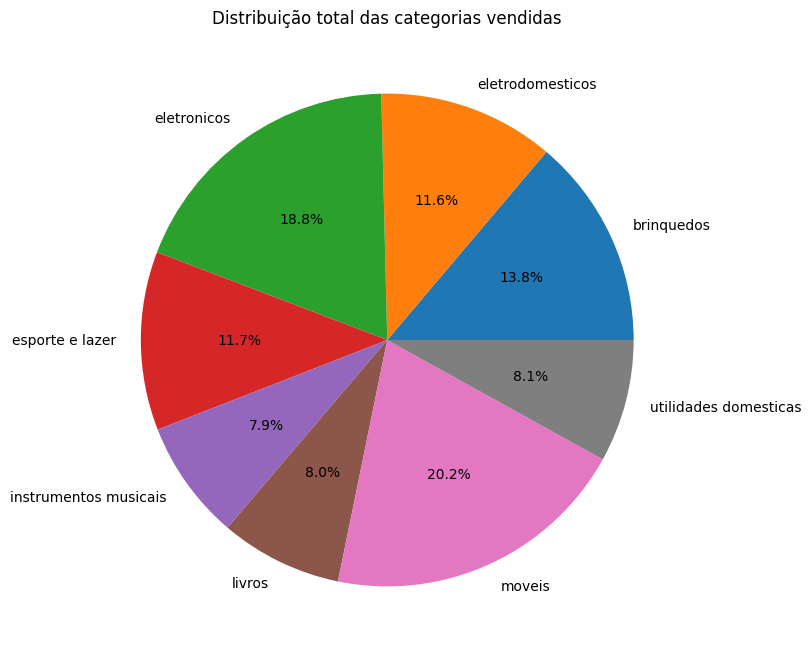

In [8]:

todas = pd.concat(lojas)
categorias_total = todas.groupby('Categoria do Produto')['Produto'].count()

plt.figure(figsize=(8,8))
plt.pie(categorias_total, labels=categorias_total.index, autopct='%1.1f%%')

plt.title("Distribuição total das categorias vendidas")
plt.show()


# GRÁFICO 3 — Frete médio por loja (LINHA)

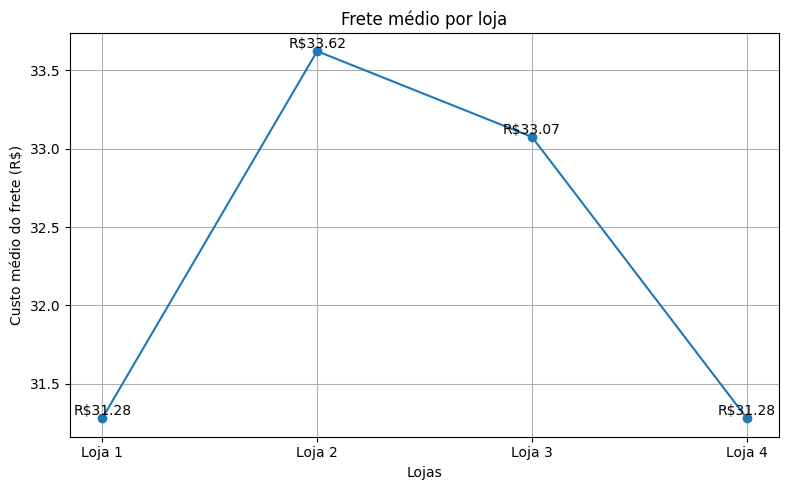

In [11]:
# --- 3. Frete médio por loja ---
fretes_medios = [
    loja['Frete'].mean(),
    loja2['Frete'].mean(),
    loja3['Frete'].mean(),
    loja4['Frete'].mean()
]

plt.figure(figsize=(8,5))
plt.plot(nomes, fretes_medios, marker='o')  # linha com pontos


for x, y in zip(nomes, fretes_medios):
    plt.text(x, y, f"R${y:.2f}", ha='center', va='bottom')

plt.title("Frete médio por loja")
plt.xlabel("Lojas")
plt.ylabel("Custo médio do frete (R$)")
plt.grid(True)
plt.tight_layout()
plt.show()


# Relatório

RELATÓRIO DE ANÁLISE DAS 4 LOJAS – RECOMENDAÇÃO DE VENDA
1. Introdução

O objetivo desta análise é identificar qual das quatro lojas apresenta o pior desempenho geral e, portanto, deve ser vendida pelo Senhor João.

Para isso, foram avaliados os seguintes indicadores:

Faturamento total de cada loja

Categorias mais vendidas

Avaliação média dos clientes

Produtos mais e menos vendidos

Frete médio por loja

Gráficos de faturamento, frete e categorias

Com base nesses dados, foi possível comparar o desempenho geral de cada loja e identificar qual unidade apresenta menor retorno e maior necessidade de descontinuidade.

2. Análise dos Indicadores
📌 2.1 Faturamento Total

Loja 1: R$ 1.534.509,12

Loja 2: R$ 1.488.459,06

Loja 3: R$ 1.464.025,03

Loja 4: R$ 1.384.497,58 ← MENOR FATURAMENTO

A Loja 4 apresenta o pior desempenho financeiro, gerando aproximadamente R$ 150.000 a menos que a líder (Loja 1) e cerca de R$ 80.000 a menos que a Loja 3.

📌 2.2 Categorias Mais Vendidas

As quatro lojas apresentam praticamente o mesmo padrão de vendas, com:

Móveis

Eletrônicos

Brinquedos

Esse padrão se repete nas 4 lojas, mostrando que o mix de produtos é igual.
Portanto, a diferença de faturamento não vem da quantidade de vendas, mas sim de outro fator.

📌 2.3 Avaliação Média dos Clientes

Loja 1: 4,00

Loja 2: 4,04

Loja 3: 4,05

Loja 4: 4,00

As avaliações são muito parecidas entre todas, não sendo um critério de desempate significativo.
Loja 4 não tem avaliação baixa — o problema não é qualidade nem atendimento.

- 2.4 Frete Médio

Loja 1: R$ 31,28

Loja 4: R$ 31,28 (mesmo valor)

Loja 3: R$ 33,07

Loja 2: R$ 33,62

A Loja 4 tem frete competitivo, igual ao da Loja 1.
Ou seja, o frete não explica o faturamento mais baixo.

- 2.5 Produtos Mais e Menos Vendidos

Os produtos mais vendidos repetem entre lojas, assim como os menos vendidos.
Isso reforça que não é um problema de demanda — a Loja 4 não vende menos itens, ela apenas valoriza menos esses itens.

3. Interpretação Geral

Ao observar todos os dados em conjunto, percebemos que:

✔ As lojas têm o mesmo volume de vendas
✔ As categorias vendidas são praticamente iguais
✔ As avaliações são muito semelhantes
✔ Os fretes não prejudicam a Loja 4

-- A única diferença real é o faturamento — e a Loja 4 é consistentemente a pior.

Isso sugere que:

A Loja 4 tem um ticket médio menor.

Ou seja, vende os mesmos produtos, mas:

com mais descontos,

preços mais baixos,

ou menor margem.

No fim das contas, ela gera menos dinheiro.

-- 4. Recomendação Final — Qual loja vender?
✅ Recomendo vender a Loja 4.
Justificativa clara e objetiva:

Menor faturamento das quatro lojas, mesmo vendendo praticamente o mesmo volume de produtos.

Mix de produtos igual às outras, portanto sem vantagem competitiva.

Avaliação satisfatória, mas sem destaque.

Frete normal, igual ao da Loja 1 (que fatura bem mais).

Não apresenta nenhum ponto forte que compense seu desempenho inferior.

-- Conclusão:

A Loja 4 é a que menos contribui para o lucro.
É a unidade com menor retorno e com menos potencial de crescimento, sendo a escolha mais adequada para descontinuidade ou venda.